In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [7]:
Data = pd.read_csv('C:\\Users\\ELGRM\\OneDrive\\Desktop\\UCI heart disease\\data\\raw\\heart_disease_uci.csv')

In [8]:
Data.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


<Axes: title={'center': 'Heart Disease Distribution'}, xlabel='num'>

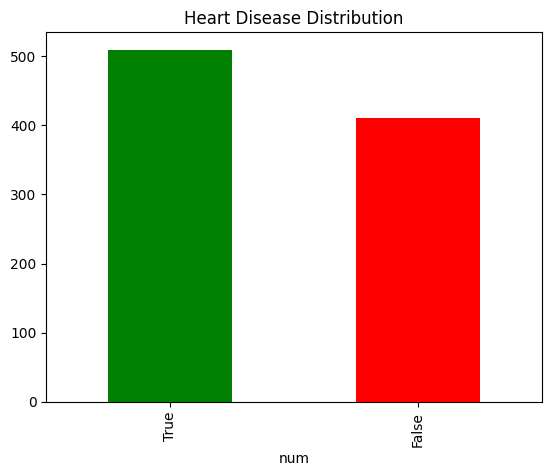

In [14]:
(Data["num"] > 0).value_counts().plot(kind='bar', title='Heart Disease Distribution', color=['green', 'red'])

In [17]:
Data.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [ ]:
Data['Target'] = Data['num'].apply(lambda x: 1 if x > 0 else 0)

In [19]:
Data.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,Target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0


In [20]:
Data.drop(columns=['num'], inplace=True)

In [32]:
Data.isna().groupby(Data['dataset']).sum()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,Target
dataset,,,,,,,,,,,,,,,,
Cleveland,0,0,0,0,0,0,0,0,0,0,0,0,1,5,3,0
Hungary,0,0,0,0,0,1,23,8,1,1,1,0,189,290,265,0
Switzerland,0,0,0,0,0,2,0,75,1,1,1,6,17,118,52,0
VA Long Beach,0,0,0,0,0,56,7,7,0,53,53,56,102,198,166,0


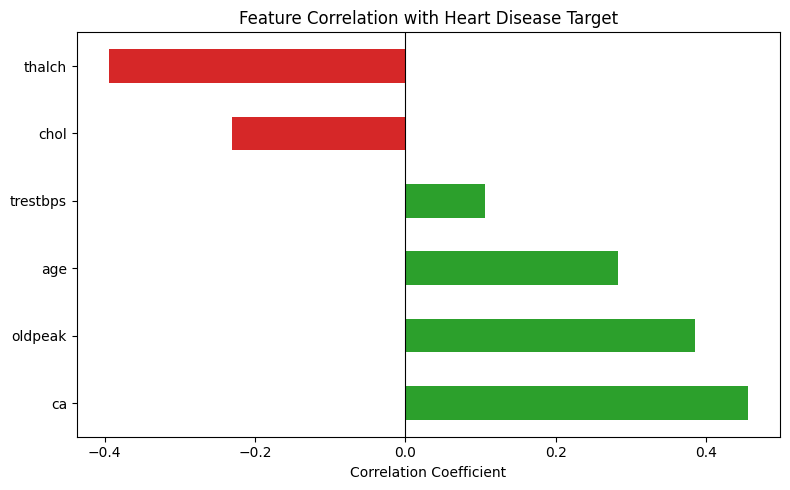

In [58]:
corr_features = Data[['age' ,'trestbps','chol','thalch','oldpeak' ,'ca']]

correlations = corr_features.corrwith(Data['target']).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
correlations.plot(kind='barh', color=['#d62728' if v < 0 else '#2ca02c' for v in correlations])
plt.title('Feature Correlation with Heart Disease Target')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


In [42]:
Data.columns = [col.lower() for col in Data.columns]
print(Data.columns.tolist())

['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
